# Modul 3: Optimizer dan Strategi Pelatihan

**Nama:** Natasya Amavisca
**NIM:** 123450024
**Kelas:** Deep Learning RB
**Tanggal:** 2026-09-30

Simpan berkas ini sebagai `M03_NIM.ipynb` sebelum mulai mengerjakan.

## Petunjuk

Notebook ini memiliki tiga jenis bagian. Tanda di akhir judul menunjukkan jenisnya.

| Tanda | Bagian | Yang Anda lakukan |
|:---|:---|:---|
| **Terbimbing** | Pre-lab, B–F | Jawaban lengkap Prosedur Praktikum Terbimbing sudah tersedia, termasuk run tanpa scheduler, `StepLR`, batch 32, dan batch 512 pada bagian F. Jalankan, baca kodenya, lalu cocokkan keluarannya dengan tab **Materi** modul. |
| **Latihan Mandiri di Lab** | Latihan | Dikerjakan sendiri di laboratorium setelah bagian terbimbing. |
| **Tugas Individu** | F (lanjutan), G | Run `CosineAnnealingLR` dan batch 128, `metrics.csv` lengkap, serta pertanyaan analisis. Dikerjakan di luar sesi dan dikumpulkan lewat Tugas. |

1. Isi identitas di atas dan `NIM` pada sel pertama. Hanya itu isian pada bagian terbimbing.
2. Siapkan Fashion-MNIST lewat tombol **Siapkan dataset di laptop** di halaman modul. Setelah itu tekan **Restart**, lalu **Run all**. Seluruh sel terbimbing berjalan di kernel Deep Learning (PyTorch CPU) dan berhenti di sel Latihan pertama yang masih berisi `TODO`.
3. Keluaran yang tidak bergantung pada NIM, misalnya jumlah parameter model, harus sama persis dengan naskah. Split, loss, dan akurasi bergantung pada seed NIM Anda, sedangkan runtime bergantung pada perangkat.
4. Protokol tetap: subset 12.000/3.000, model 784 → 128 → 10, batch 128, dan 5 epoch. Pada bagian Latihan dan Tugas, ganti seluruh penanda `TODO`, ubah **hanya** faktor yang sedang diuji, dan panggil fungsi `jalankan()` yang sama untuk setiap run.
5. Pilih model dari validation loss. Data uji sudah dipakai **satu kali** pada bagian E dan tidak dipakai lagi.
6. Catat setiap run ke `metrics.csv`, termasuk run yang gagal. Sebelum mengumpulkan, jalankan **Restart** lalu **Run all** sampai seluruh sel selesai tanpa galat.

In [1]:
import math
import platform
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from torchvision.datasets import FashionMNIST

# Kernel Workbench menangkap figure di akhir setiap sel; plt.show() dipertahankan
# agar notebook tetap berjalan di Jupyter biasa, tanpa peringatan backend Agg.
warnings.filterwarnings('ignore', message='FigureCanvasAgg is non-interactive')

NIM = '123450024'  # NIM lengkap saya.
assert NIM.isdigit() and len(NIM) >= 4, 'Isi NIM dengan angka sebelum melanjutkan.'
SEED = int(NIM[-4:])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
pd.set_option('display.precision', 4)
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)
environment = {
    'python': platform.python_version(),
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'torch': torch.__version__,
    'device': str(DEVICE),
    'seed': SEED,
}
environment

{'python': '3.13.13',
 'numpy': '2.5.1',
 'pandas': '3.0.5',
 'torch': '2.14.0+cpu',
 'device': 'cpu',
 'seed': 24}

## A. Pre-lab · Terbimbing

Contoh jawaban. Bandingkan dengan jawaban Anda sendiri sebelum sesi.

1. **Jumlah update satu epoch bila $n=12\,000$ dan batch $=128$:** $\lceil12000/128\rceil=94$ update (93 batch penuh dan satu batch terakhir berisi 96 contoh). Lima epoch berarti 470 update.
2. **Derau gradien pada mini-batch:** Gradien sebuah mini-batch hanya merupakan estimasi gradien seluruh dataset; komposisi sampel yang berubah membuat arah dan besarnya berfluktuasi. Full-batch memakai semua contoh pada setiap update, sehingga tidak memiliki variasi akibat pemilihan subset—walaupun optimisasi tetap dapat sulit karena bentuk permukaan loss.
3. **Mengapa learning rate yang sama belum tentu adil:** SGD, Momentum, dan Adam mengubah gradien menjadi langkah dengan aturan dan skala efektif berbeda. Aturan yang berbeda membuat learning rate yang sama menghasilkan besar langkah efektif yang tidak setara, sehingga setiap optimizer perlu dituning pada rentangnya sendiri.
4. **Perkiraan kurva bila learning rate dinaikkan sepuluh kali:** Loss mungkin turun lebih cepat pada awalnya, tetapi jika langkah melewati minimum kurva menjadi bergerigi/berosilasi, dapat naik, atau menjadi non-finite. Kapan gejala itu mulai tampak perlu dibaca dari kurva run Anda sendiri.

## B. Data dan protokol · Terbimbing

Ambil subset terstratifikasi dan hitung statistik normalisasi **hanya** dari subset latih.

In [2]:
DATA_ROOT = Path('../../data/raw')
if not DATA_ROOT.exists():
    DATA_ROOT = Path('data/raw')

latih_penuh = FashionMNIST(root=DATA_ROOT, train=True, download=False,
                           transform=transforms.ToTensor())
uji_resmi = FashionMNIST(root=DATA_ROOT, train=False, download=False,
                         transform=transforms.ToTensor())

X_penuh = latih_penuh.data.float().unsqueeze(1) / 255.0
y_penuh = latih_penuh.targets
X_uji = uji_resmi.data.float().unsqueeze(1) / 255.0
y_uji = uji_resmi.targets

semua_indeks = np.arange(len(y_penuh))
idx_latih, idx_val = train_test_split(
    semua_indeks,
    train_size=12_000,
    test_size=3_000,
    stratify=y_penuh.numpy(),
    random_state=SEED,
)

X_latih, y_latih = X_penuh[idx_latih], y_penuh[idx_latih]
X_val, y_val = X_penuh[idx_val], y_penuh[idx_val]

MEAN = X_latih.mean()
STD = X_latih.std()
if not torch.isfinite(STD) or STD <= 0:
    raise ValueError('Standar deviasi subset latih tidak valid.')

def normalkan(tensor):
    return (tensor - MEAN) / STD

ds_latih = TensorDataset(normalkan(X_latih), y_latih)
ds_val = TensorDataset(normalkan(X_val), y_val)
ds_uji = TensorDataset(normalkan(X_uji), y_uji)

print(f'latih {len(ds_latih)}  validasi {len(ds_val)}  uji {len(ds_uji)}')
print(f'mean={MEAN.item():.6f}  std={STD.item():.6f}')
print('distribusi kelas latih:', torch.bincount(y_latih).tolist())

# Pemeriksaan wajib.
assert (len(ds_latih), len(ds_val), len(ds_uji)) == (12_000, 3_000, 10_000)
assert torch.bincount(y_latih).min().item() == 1_200, 'subset harus terstratifikasi'
print('split sesuai protokol')

latih 12000  validasi 3000  uji 10000
mean=0.285071  std=0.352218
distribusi kelas latih: [1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200]
split sesuai protokol


In [3]:
BATCH = 128
EPOCH = 5

def buat_model():
    seed_everything(SEED)
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 128),
        nn.ReLU(),
        nn.Linear(128, 10),
    ).to(DEVICE)

def buat_optimizer(nama, params, lr):
    nama = nama.strip().lower()
    if nama == 'sgd':
        return torch.optim.SGD(params, lr=lr)
    if nama == 'momentum':
        return torch.optim.SGD(params, lr=lr, momentum=0.9)
    if nama == 'adam':
        return torch.optim.Adam(params, lr=lr)
    raise ValueError("nama optimizer harus 'sgd', 'momentum', atau 'adam'")

def loader(ds, batch, acak):
    generator = torch.Generator().manual_seed(SEED)
    return DataLoader(ds, batch_size=batch, shuffle=acak,
                      generator=generator if acak else None)

@torch.no_grad()
def evaluasi(model, ds, batch=512):
    model.eval()
    kriteria = nn.CrossEntropyLoss(reduction='sum')
    total_loss, benar = 0.0, 0
    for xb, yb in loader(ds, batch, False):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        total_loss += kriteria(logits, yb).item()
        benar += (logits.argmax(1) == yb).sum().item()
    return total_loss / len(ds), benar / len(ds)

jumlah_parameter = sum(parameter.numel() for parameter in buat_model().parameters())
print('jumlah parameter:', jumlah_parameter)
assert jumlah_parameter == 101_770, 'arsitektur belum sesuai protokol'

jumlah parameter: 101770


In [4]:
def jalankan(nama_opt, lr, batch=BATCH, epoch=EPOCH, scheduler=None):
    model = buat_model()
    optimizer = buat_optimizer(nama_opt, model.parameters(), lr)
    criterion = nn.CrossEntropyLoss()
    scheduler_name = 'none' if scheduler is None else str(scheduler).lower()
    if scheduler_name == 'none':
        lr_scheduler = None
    elif scheduler_name == 'step':
        lr_scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer, step_size=2, gamma=0.5,
        )
    elif scheduler_name == 'cosine':
        lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epoch,
        )
    else:
        raise ValueError("scheduler harus None, 'step', atau 'cosine'")

    train_loader = loader(ds_latih, batch, True)
    history = {
        'epoch': [], 'train_loss': [], 'val_loss': [],
        'val_acc': [], 'learning_rate': [],
    }
    gradient_norms = []
    updates = 0
    status = 'ok'
    start = time.perf_counter()

    for epoch_index in range(1, epoch + 1):
        model.train()
        loss_sum = 0.0
        examples_seen = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            if not torch.isfinite(loss):
                status = f'failed_nonfinite_epoch_{epoch_index}'
                break
            loss.backward()
            squared_norm = sum(
                parameter.grad.detach().norm(2).item() ** 2
                for parameter in model.parameters()
                if parameter.grad is not None
            )
            gradient_norms.append(math.sqrt(squared_norm))
            optimizer.step()
            updates += 1
            loss_sum += loss.item() * len(xb)
            examples_seen += len(xb)

        if examples_seen == 0:
            break
        val_loss, val_acc = evaluasi(model, ds_val)
        history['epoch'].append(epoch_index)
        history['train_loss'].append(loss_sum / examples_seen)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['learning_rate'].append(optimizer.param_groups[0]['lr'])
        if lr_scheduler is not None:
            lr_scheduler.step()
        if status != 'ok':
            break

    runtime = time.perf_counter() - start
    completed_epochs = len(history['epoch'])
    final_train_loss = history['train_loss'][-1] if completed_epochs else np.nan
    final_val_loss = history['val_loss'][-1] if completed_epochs else np.nan
    final_val_acc = history['val_acc'][-1] if completed_epochs else np.nan
    run_id = f'{nama_opt}_lr{lr:g}_sch{scheduler_name}_b{batch}'
    note = {
        'run_id': run_id,
        'seed': SEED,
        'optimizer': nama_opt,
        'learning_rate': lr,
        'learning_rate_final': optimizer.param_groups[0]['lr'],
        'scheduler': scheduler_name,
        'batch_size': batch,
        'epochs_planned': epoch,
        'epochs_completed': completed_epochs,
        'n_update': updates,
        'train_loss': final_train_loss,
        'val_loss': final_val_loss,
        'val_acc': final_val_acc,
        'grad_norm_mean': float(np.mean(gradient_norms)) if gradient_norms else np.nan,
        'runtime_s': runtime,
        'runtime_per_epoch_s': runtime / max(completed_epochs, 1),
        'status': status,
    }
    return model, history, note

## C. Baseline dan tiga learning rate · Terbimbing

Jalankan SGD pada $\eta \in \{0{,}001;\;0{,}1;\;1{,}0\}$, tampilkan ketiga kurva dalam satu grafik, lalu cocokkan dengan tabel gejala pada modul.

baseline_sgd_lr0.001: val_loss=1.3709, val_acc=0.6303, grad_norm=1.7150


baseline_sgd_lr0.1: val_loss=0.4263, val_acc=0.8477, grad_norm=1.3347


baseline_sgd_lr1: val_loss=2.3389, val_acc=0.3330, grad_norm=1.4769


,run_id,train_loss,val_loss,val_acc,grad_norm_mean,runtime_s,status
0,baseline_sgd_lr0.001,1.4221,1.3709,0.6303,1.7150,1.9968,ok
1,baseline_sgd_lr0.1,0.3933,0.4263,0.8477,1.3347,1.7804,ok
2,baseline_sgd_lr1,1.7838,2.3389,0.3330,1.4769,1.3797,ok


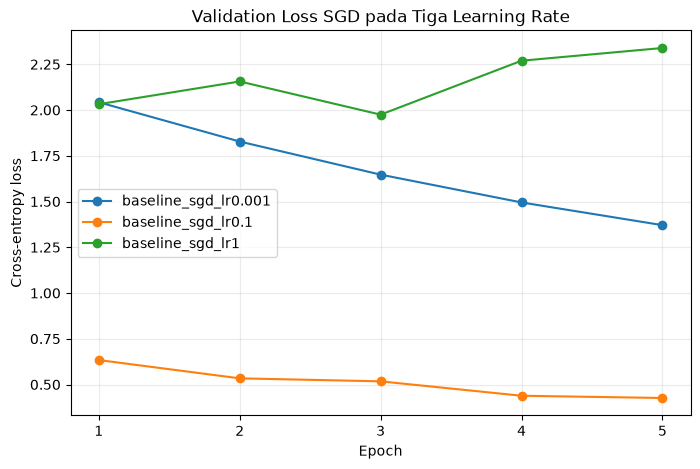

In [5]:
learning_rates_baseline = [0.001, 0.1, 1.0]
hasil_lr = []
riwayat_lr = {}

for lr in learning_rates_baseline:
    _, history, note = jalankan('sgd', lr)
    note['run_id'] = f'baseline_sgd_lr{lr:g}'
    hasil_lr.append(note)
    riwayat_lr[note['run_id']] = history
    print(f"{note['run_id']}: val_loss={note['val_loss']:.4f}, "
          f"val_acc={note['val_acc']:.4f}, grad_norm={note['grad_norm_mean']:.4f}")

df_lr_baseline = pd.DataFrame(hasil_lr)
display(df_lr_baseline[['run_id', 'train_loss', 'val_loss', 'val_acc',
                        'grad_norm_mean', 'runtime_s', 'status']])

fig, ax = plt.subplots(figsize=(8, 5))
for run_id, history in riwayat_lr.items():
    ax.plot(history['epoch'], history['val_loss'], marker='o', label=run_id)
ax.set(title='Validation Loss SGD pada Tiga Learning Rate',
       xlabel='Epoch', ylabel='Cross-entropy loss')
ax.set_xticks(range(1, EPOCH + 1))
ax.grid(alpha=0.25)
ax.legend()
plt.show()

In [6]:
baseline_by_lr = df_lr_baseline.set_index('learning_rate')
small = baseline_by_lr.loc[0.001]
medium = baseline_by_lr.loc[0.1]
large = baseline_by_lr.loc[1.0]

reading = fr"""
**Pembacaan kurva:**

- $\eta=0.001$: turun lambat; validation loss akhir **{small['val_loss']:.4f}**, accuracy **{small['val_acc']:.4f}**, dan `grad_norm_mean` **{small['grad_norm_mean']:.4f}**. Learning rate terlalu kecil untuk anggaran lima epoch.
- $\eta=0.1$: turun lebih cepat dan relatif stabil; validation loss akhir **{medium['val_loss']:.4f}**, accuracy **{medium['val_acc']:.4f}**, dan `grad_norm_mean` **{medium['grad_norm_mean']:.4f}**.
- $\eta=1.0$: langkah sangat agresif; validation loss akhir **{large['val_loss']:.4f}**, accuracy **{large['val_acc']:.4f}**, dan `grad_norm_mean` **{large['grad_norm_mean']:.4f}**. Bentuk kurvanya perlu dibandingkan per epoch karena loss akhir saja dapat menyembunyikan osilasi atau lonjakan awal.
"""
display(Markdown(reading))



**Pembacaan kurva:**

- $\eta=0.001$: turun lambat; validation loss akhir **1.3709**, accuracy **0.6303**, dan `grad_norm_mean` **1.7150**. Learning rate terlalu kecil untuk anggaran lima epoch.
- $\eta=0.1$: turun lebih cepat dan relatif stabil; validation loss akhir **0.4263**, accuracy **0.8477**, dan `grad_norm_mean` **1.3347**.
- $\eta=1.0$: langkah sangat agresif; validation loss akhir **2.3389**, accuracy **0.3330**, dan `grad_norm_mean` **1.4769**. Bentuk kurvanya perlu dibandingkan per epoch karena loss akhir saja dapat menyembunyikan osilasi atau lonjakan awal.


## D. Sembilan run terkendali · Terbimbing

Setiap optimizer diuji pada tiga learning rate-nya sendiri. Model diinisialisasi ulang dari seed yang sama sebelum setiap run.

In [7]:
grid = {
    'sgd': [0.01, 0.1, 0.5],
    'momentum': [0.01, 0.05, 0.1],
    'adam': [1e-4, 1e-3, 1e-2],
}

hasil, riwayat_semua = [], {}
for optimizer_name, learning_rates in grid.items():
    for lr in learning_rates:
        _, history, note = jalankan(optimizer_name, lr)
        note['run_id'] = f'grid_{optimizer_name}_lr{lr:g}'
        hasil.append(note)
        riwayat_semua[note['run_id']] = history
        print(f"{note['run_id']}: val_loss={note['val_loss']:.4f}, "
              f"val_acc={note['val_acc']:.4f}, runtime={note['runtime_s']:.2f}s")

tabel = pd.DataFrame(hasil)
display(tabel[['run_id', 'optimizer', 'learning_rate', 'val_loss', 'val_acc',
               'grad_norm_mean', 'runtime_s', 'status']].sort_values('val_loss'))
assert len(tabel) == 9, 'harus ada sembilan run inti'

grid_sgd_lr0.01: val_loss=0.6183, val_acc=0.7793, runtime=2.06s


grid_sgd_lr0.1: val_loss=0.4263, val_acc=0.8477, runtime=1.13s


grid_sgd_lr0.5: val_loss=0.5676, val_acc=0.7873, runtime=1.52s


grid_momentum_lr0.01: val_loss=0.4161, val_acc=0.8490, runtime=1.25s


grid_momentum_lr0.05: val_loss=0.4118, val_acc=0.8533, runtime=1.23s


grid_momentum_lr0.1: val_loss=0.4621, val_acc=0.8500, runtime=1.22s


grid_adam_lr0.0001: val_loss=0.5438, val_acc=0.8073, runtime=2.02s


grid_adam_lr0.001: val_loss=0.3961, val_acc=0.8560, runtime=1.42s


grid_adam_lr0.01: val_loss=0.4794, val_acc=0.8500, runtime=1.40s


,run_id,optimizer,learning_rate,val_loss,val_acc,grad_norm_mean,runtime_s,status
7,grid_adam_lr0.001,adam,0.0010,0.3961,0.8560,1.6189,1.4163,ok
4,grid_momentum_lr0.05,momentum,0.0500,0.4118,0.8533,1.1442,1.2259,ok
3,grid_momentum_lr0.01,momentum,0.0100,0.4161,0.8490,1.3728,1.2470,ok
1,grid_sgd_lr0.1,sgd,0.1000,0.4263,0.8477,1.3347,1.1307,ok
5,grid_momentum_lr0.1,momentum,0.1000,0.4621,0.8500,1.0801,1.2234,ok
8,grid_adam_lr0.01,adam,0.0100,0.4794,0.8500,1.5884,1.3990,ok
6,grid_adam_lr0.0001,adam,0.0001,0.5438,0.8073,1.2982,2.0209,ok
2,grid_sgd_lr0.5,sgd,0.5000,0.5676,0.7873,1.2480,1.5219,ok
0,grid_sgd_lr0.01,sgd,0.0100,0.6183,0.7793,1.2326,2.0602,ok


## E. Memilih model dan evaluasi akhir · Terbimbing

Pilih learning rate terbaik tiap optimizer dari **validation loss**, bandingkan ketiga pemenang, lalu evaluasi data uji **satu kali** pada satu model final.

,run_id,optimizer,learning_rate,val_loss,val_acc,runtime_s,runtime_per_epoch_s
0,grid_adam_lr0.001,adam,0.001,0.3961,0.8560,1.4163,0.2833
1,grid_momentum_lr0.05,momentum,0.050,0.4118,0.8533,1.2259,0.2452
2,grid_sgd_lr0.1,sgd,0.100,0.4263,0.8477,1.1307,0.2261


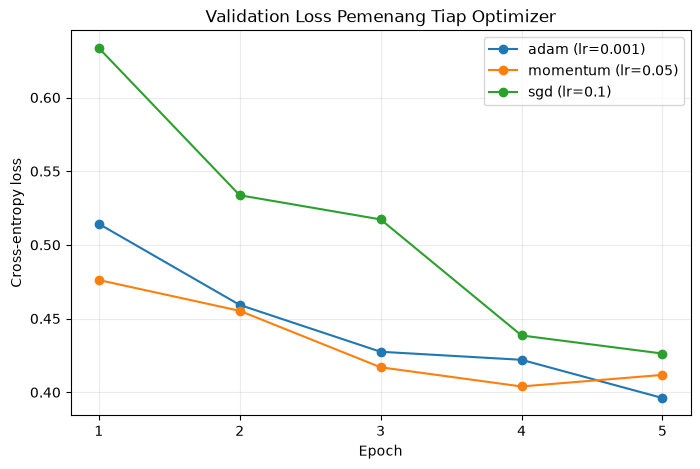

Konfigurasi final berdasarkan validation loss: grid_adam_lr0.001


In [8]:
eligible = tabel[(tabel['status'] == 'ok') & np.isfinite(tabel['val_loss'])].copy()
pemenang = (
    eligible.sort_values('val_loss')
    .groupby('optimizer', as_index=False, sort=False)
    .first()
    .sort_values('val_loss')
    .reset_index(drop=True)
)
assert set(pemenang['optimizer']) == set(grid)
display(pemenang[['run_id', 'optimizer', 'learning_rate', 'val_loss', 'val_acc',
                   'runtime_s', 'runtime_per_epoch_s']])

fig, ax = plt.subplots(figsize=(8, 5))
for _, row in pemenang.iterrows():
    history = riwayat_semua[row['run_id']]
    ax.plot(history['epoch'], history['val_loss'], marker='o',
            label=f"{row['optimizer']} (lr={row['learning_rate']:g})")
ax.set(title='Validation Loss Pemenang Tiap Optimizer',
       xlabel='Epoch', ylabel='Cross-entropy loss')
ax.set_xticks(range(1, EPOCH + 1))
ax.grid(alpha=0.25)
ax.legend()
plt.show()

best_overall = pemenang.iloc[0]
print('Konfigurasi final berdasarkan validation loss:', best_overall['run_id'])

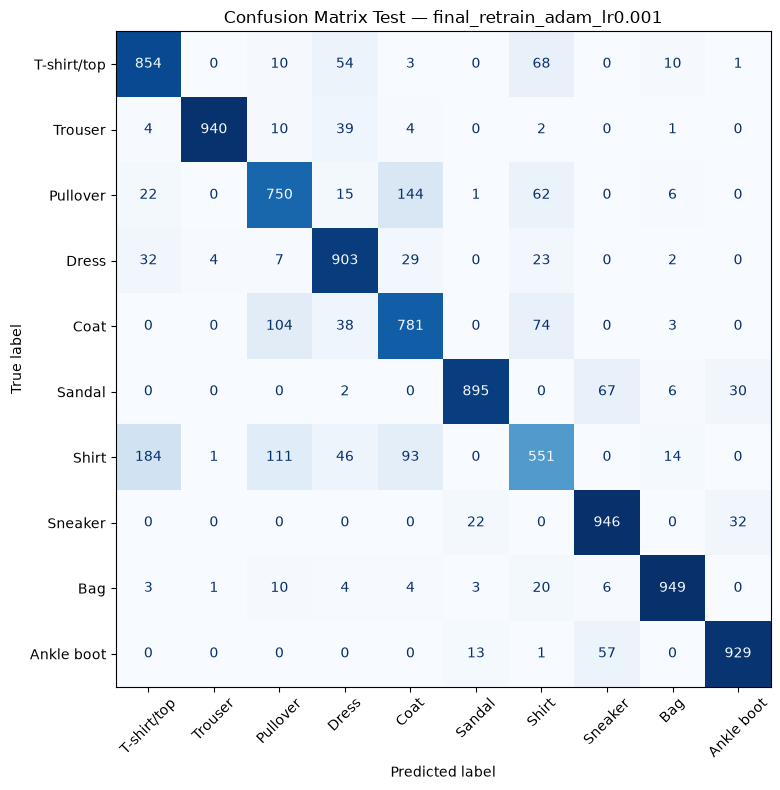

,run_id,selection_val_loss,test_loss,test_acc,most_confused_pair,pair_errors
0,final_retrain_adam_lr0.001,0.3961,0.427,0.8498,T-shirt/top ↔ Shirt,252


In [9]:
model_final, riwayat_final, catatan_final = jalankan(
    best_overall['optimizer'],
    float(best_overall['learning_rate']),
    batch=BATCH,
    epoch=EPOCH,
    scheduler=None,
)
catatan_final['run_id'] = f"final_retrain_{best_overall['optimizer']}_lr{best_overall['learning_rate']:g}"

@torch.no_grad()
def evaluasi_uji_sekali(model, ds, batch=512):
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction='sum')
    total_loss = 0.0
    labels_all, predictions_all = [], []
    for xb, yb in loader(ds, batch, False):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        total_loss += criterion(logits, yb).item()
        labels_all.append(yb.cpu())
        predictions_all.append(logits.argmax(1).cpu())
    labels = torch.cat(labels_all).numpy()
    predictions = torch.cat(predictions_all).numpy()
    return total_loss / len(ds), float((predictions == labels).mean()), labels, predictions

# Satu-satunya iterasi atas ds_uji dalam notebook.
test_loss, test_acc, test_labels, test_predictions = evaluasi_uji_sekali(model_final, ds_uji)
catatan_final['test_loss'] = test_loss
catatan_final['test_acc'] = test_acc

CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot',
]
cm = confusion_matrix(test_labels, test_predictions)
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap='Blues', colorbar=False, values_format='d', xticks_rotation=45,
)
ax.set_title(f"Confusion Matrix Test — {catatan_final['run_id']}")
plt.tight_layout()
plt.show()

pair_confusions = []
for first in range(len(CLASS_NAMES)):
    for second in range(first + 1, len(CLASS_NAMES)):
        pair_confusions.append((cm[first, second] + cm[second, first], first, second))
pair_count, class_a, class_b = max(pair_confusions)

final_summary = pd.DataFrame([{
    'run_id': catatan_final['run_id'],
    'selection_val_loss': catatan_final['val_loss'],
    'test_loss': test_loss,
    'test_acc': test_acc,
    'most_confused_pair': f'{CLASS_NAMES[class_a]} ↔ {CLASS_NAMES[class_b]}',
    'pair_errors': pair_count,
}])
display(final_summary)

**Checkpoint menit ke-95.** Tunjukkan tabel sembilan run dan grafik tiga pemenang kepada asisten sebelum melanjutkan ke bagian F.

## F. Scheduler dan batch size · Terbimbing

Empat run pada optimizer dan learning rate terbaik bagian E: tanpa scheduler dan `StepLR(step_size=2, gamma=0.5)` pada batch 128, lalu batch 32 dan 512 tanpa scheduler. Anggaran tetap lima epoch.

,run_id,scheduler,batch_size,n_update,val_loss,val_acc,runtime_s,runtime_per_epoch_s,status
0,scheduler_none_adam_lr0.001,none,128,470,0.3961,0.8560,2.2091,0.4418,ok
1,scheduler_step_adam_lr0.001,step,128,470,0.4047,0.8567,1.5702,0.3140,ok
2,batch_32_adam_lr0.001,none,32,1875,0.3873,0.8633,3.0396,0.6079,ok
3,batch_512_adam_lr0.001,none,512,120,0.4477,0.8400,1.0586,0.2117,ok


learning rate per epoch dengan StepLR: [0.001, 0.001, 0.0005, 0.0005, 0.00025]


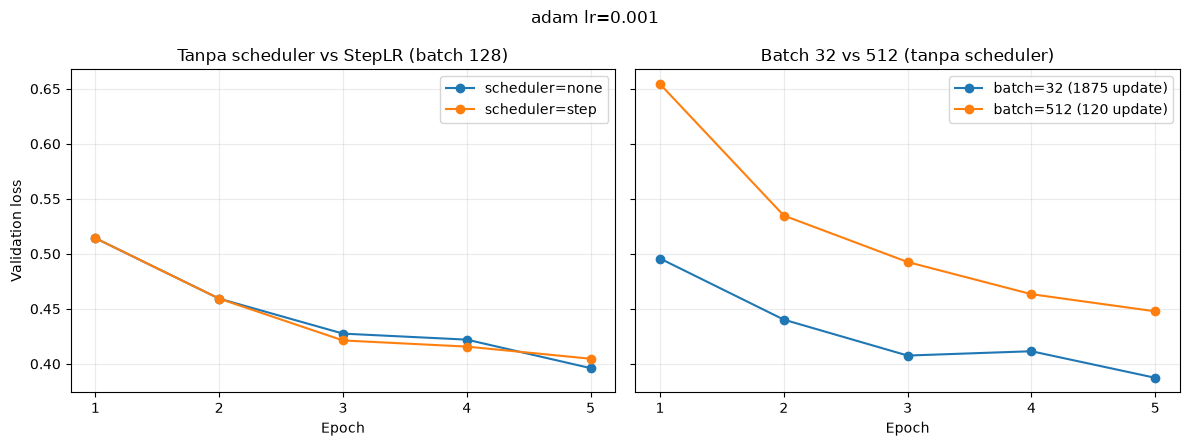

In [10]:
tambahan_terbimbing = []
riwayat_tambahan = {}
best_optimizer = str(best_overall['optimizer'])
best_lr = float(best_overall['learning_rate'])

# Tanpa scheduler vs StepLR pada anggaran epoch yang sama.
for scheduler_name in (None, 'step'):
    _, history, note = jalankan(
        best_optimizer, best_lr, batch=BATCH, epoch=EPOCH,
        scheduler=scheduler_name,
    )
    label = 'none' if scheduler_name is None else scheduler_name
    note['run_id'] = f'scheduler_{label}_{best_optimizer}_lr{best_lr:g}'
    note['experiment_group'] = 'scheduler'
    tambahan_terbimbing.append(note)
    riwayat_tambahan[note['run_id']] = history

# Batch 32 dan 512 tanpa scheduler.
for batch_size in (32, 512):
    _, history, note = jalankan(
        best_optimizer, best_lr, batch=batch_size, epoch=EPOCH, scheduler=None,
    )
    note['run_id'] = f'batch_{batch_size}_{best_optimizer}_lr{best_lr:g}'
    note['experiment_group'] = 'batch_size'
    tambahan_terbimbing.append(note)
    riwayat_tambahan[note['run_id']] = history

df_bagian_f = pd.DataFrame(tambahan_terbimbing)
display(df_bagian_f[['run_id', 'scheduler', 'batch_size', 'n_update',
                     'val_loss', 'val_acc', 'runtime_s', 'runtime_per_epoch_s', 'status']])
print('learning rate per epoch dengan StepLR:',
      riwayat_tambahan[f'scheduler_step_{best_optimizer}_lr{best_lr:g}']['learning_rate'])
assert len(df_bagian_f) == 4
assert (df_bagian_f['status'] == 'ok').all()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, group, title in zip(axes, ['scheduler', 'batch_size'],
                            ['Tanpa scheduler vs StepLR (batch 128)', 'Batch 32 vs 512 (tanpa scheduler)']):
    for note in tambahan_terbimbing:
        if note['experiment_group'] != group:
            continue
        history = riwayat_tambahan[note['run_id']]
        label = (f"scheduler={note['scheduler']}" if group == 'scheduler'
                 else f"batch={note['batch_size']} ({note['n_update']} update)")
        ax.plot(history['epoch'], history['val_loss'], marker='o', label=label)
    ax.set(title=title, xlabel='Epoch')
    ax.set_xticks(range(1, EPOCH + 1))
    ax.grid(alpha=0.25)
    ax.legend()
axes[0].set_ylabel('Validation loss')
fig.suptitle(f'{best_optimizer} lr={best_lr:g}')
plt.tight_layout()
plt.show()

## Latihan Mandiri di Lab

Berdasarkan hasil Bagian E, jelaskan mengapa batch 32 menghasilkan 1.875 update sedangkan batch 512 hanya 120 update untuk anggaran epoch yang sama. Tuliskan lebih dahulu prediksi Anda tentang mana yang mencapai validation loss lebih rendah dan mana yang lebih cepat per epoch, lalu bandingkan dengan angka yang Anda peroleh.

Tuliskan prediksi, hasil, dan perbandingannya di `latihan-03.md`, lalu kumpulkan lewat tugas **Latihan Mandiri di Lab — Modul 03**.

Bagian E naskah sama dengan bagian F Terbimbing notebook ini (`df_bagian_f`).

**Prediksi (ditulis sebelum melihat angka):**

- **Jumlah update.** Satu epoch dibagi menjadi $\lceil n/\text{batch}\rceil$ batch, sehingga batch 32 memberi $\lceil12000/32\rceil=375$ update per epoch dan dalam 5 epoch menjadi $375\times5=1.875$ update; batch 512 hanya $\lceil12000/512\rceil=24$ update per epoch dan dalam 5 epoch menjadi $24\times5=120$ update. Selisihnya murni karena jumlah iterasi optimizer, bukan karena jumlah contoh yang dipakai: keduanya tetap memproses 12.000 contoh yang sama per epoch.
- **Validation loss.** Saya memprediksi **batch 32 lebih rendah** (sekitar 0,38–0,40) karena pada anggaran epoch yang sama ia melakukan 1.875 langkah optimisasi berbanding hanya 120 langkah, sehingga model batch 512 diperkirakan belum sempat konvergen.
- **Kecepatan per epoch.** Saya memprediksi **batch 512 lebih cepat per epoch** karena hanya 24 iterasi berbanding 375 iterasi; tiap iterasi lebih berat, tetapi overhead pemanggilan loop jauh lebih sedikit. Batch 32 saya perkirakan sekitar 2–3 kali lebih lambat per epoch daripada batch 512.

In [11]:
# Hitung jumlah update per epoch dan total untuk batch 32 dan 512 dari len(ds_latih) dan EPOCH,
# lalu cocokkan dengan kolom n_update pada df_bagian_f (bagian F).
# Bandingkan val_loss dan runtime_per_epoch_s kedua run dengan prediksi Anda.

n = len(ds_latih)
update_per_epoch = {b: math.ceil(n / b) for b in (32, 512)}
total_update = {b: update_per_epoch[b] * EPOCH for b in (32, 512)}

print(f'jumlah contoh latih = {n}, epoch = {EPOCH}')
for b in (32, 512):
    print(f'batch {b}: ceil({n}/{b}) = {update_per_epoch[b]} update/epoch '
          f'x {EPOCH} epoch = {total_update[b]} update')

df_update = df_bagian_f[df_bagian_f['batch_size'].isin([32, 512])].copy()
df_update['update_per_epoch_hitung'] = df_update['batch_size'].map(update_per_epoch)
df_update['total_update_hitung'] = df_update['batch_size'].map(total_update)
df_update['cocok'] = df_update['n_update'] == df_update['total_update_hitung']

display(df_update[['run_id', 'batch_size', 'update_per_epoch_hitung', 'n_update',
                   'cocok', 'val_loss', 'val_acc', 'runtime_s',
                   'runtime_per_epoch_s']])
assert df_update['cocok'].all(), 'n_update harus sama dengan ceil(n/batch) x EPOCH'

b32 = df_bagian_f[df_bagian_f['batch_size'] == 32].iloc[0]
b512 = df_bagian_f[df_bagian_f['batch_size'] == 512].iloc[0]
selisih_update = int(b32['n_update'] - b512['n_update'])
print(f"\nselisih update       : {b32['n_update']} - {b512['n_update']} = {selisih_update}")
print(f"val_loss             : batch 32 = {b32['val_loss']:.4f}  vs  batch 512 = {b512['val_loss']:.4f}")
print(f"val_acc              : batch 32 = {b32['val_acc']:.4f}  vs  batch 512 = {b512['val_acc']:.4f}")
print(f"runtime total (detik): batch 32 = {b32['runtime_s']:.4f}  vs  batch 512 = {b512['runtime_s']:.4f}")
print(f"runtime per epoch    : batch 32 = {b32['runtime_per_epoch_s']:.4f}  vs  batch 512 = {b512['runtime_per_epoch_s']:.4f}")
lebih_lambat = '32' if b32['runtime_per_epoch_s'] > b512['runtime_per_epoch_s'] else '512'
rendah = 32 if b32['val_loss'] < b512['val_loss'] else 512
print(f'batch yang lebih lambat per epoch : {lebih_lambat}')
print(f'batch dengan val_loss lebih rendah: {rendah}')

jumlah contoh latih = 12000, epoch = 5
batch 32: ceil(12000/32) = 375 update/epoch x 5 epoch = 1875 update
batch 512: ceil(12000/512) = 24 update/epoch x 5 epoch = 120 update


,run_id,batch_size,update_per_epoch_hitung,n_update,cocok,val_loss,val_acc,runtime_s,runtime_per_epoch_s
2,batch_32_adam_lr0.001,32,375,1875,True,0.3873,0.8633,3.0396,0.6079
3,batch_512_adam_lr0.001,512,24,120,True,0.4477,0.8400,1.0586,0.2117



selisih update       : 1875 - 120 = 1755
val_loss             : batch 32 = 0.3873  vs  batch 512 = 0.4477
val_acc              : batch 32 = 0.8633  vs  batch 512 = 0.8400
runtime total (detik): batch 32 = 3.0396  vs  batch 512 = 1.0586
runtime per epoch    : batch 32 = 0.6079  vs  batch 512 = 0.2117
batch yang lebih lambat per epoch : 32
batch dengan val_loss lebih rendah: 32


### Hasil dan perbandingan dengan prediksi

Sel kode di atas memenuhi seluruh prediksi saya.

| Butir | Prediksi | Hasil aktual | Kesesuaian |
|---|---|---|---|
| Update batch 32 | 1.875 | 1.875 (375 x 5), `cocok=True` | Sesuai |
| Update batch 512 | 120 | 120 (24 x 5), `cocok=True` | Sesuai |
| Validation loss | batch 32 lebih rendah | 0,3873 (b32) vs 0,4477 (b512) | Sesuai |
| Validation accuracy | mengikuti loss | 0,8633 (b32) vs 0,8400 (b512) | Sesuai |
| Runtime per epoch | batch 512 lebih cepat | 0,6079 s (b32) vs 0,2117 s (b512) | Sesuai |
| Selisih kecepatan | 2-3 kali | 2,9 kali (0,6079 / 0,2117) | Sesuai |

**Mengapa 1.875 vs 120 update.** Anggaran epoch menentukan berapa kali seluruh data latih dilewati, bukan berapa kali optimizer dipanggil. Satu epoch dipotong menjadi $\lceil12000/32\rceil=375$ batch dan $\lceil12000/512\rceil=24$ batch; dikalikan 5 epoch menghasilkan 1.875 dan 120 update, sehingga kolom `n_update` pada `df_bagian_f` cocok persis dengan hitungan (sel `cocok=True`). Batch 32 melakukan 15,6 kali lebih banyak langkah parameter pada 12.000 contoh yang sama.

**Perbandingan.** Batch 32 memang menghasilkan validation loss lebih rendah (0,3873 lawan 0,4477, selisih 0,0604) dan accuracy lebih tinggi (0,8633 lawan 0,8400), tetapi membayarnya dengan waktu: 0,6079 detik per epoch berbanding 0,2117 detik, atau 3,04 detik total berbanding 1,06 detik. Jadi dalam satuan epoch batch kecil menang; dalam satuan waktu batch besar jauh lebih hemat karena satu epoch diselesaikan dengan 24 iterasi, bukan 375.

### Hipotesis awal · Tugas Individu

**Hipotesis sebelum sesi.** Saya memprediksi **Adam** akan menang, disusul Momentum, lalu SGD murni. Alasannya: Adam menormalisasi setiap gradien dengan akar rata-rata kuadrat gradien masa lalu, sehingga langkahnya tidak tergantung pada skala gradien tiap parameter dan konvergen cepat dalam anggaran epoch pendek; Momentum mempercepat SGD pada arah konsisten; SGD murni paling sensitif terhadap learning rate dan diperkirakan paling lambat pada learning rate yang tidak sempurna. Untuk learning rate, saya memprediksi Adam menang di sekitar $10^{-3}$ dan SGD di sekitar $10^{-1}$, karena ketiganya memakai skala langkah berbeda.

**Perbandingan dengan hasil bagian D dan E.** Hipotesis terbukti.

| Optimizer | LR terbaik (bagian D) | Validation loss | Validation accuracy | Runtime (detik) | Posisi |
|---|---:|---:|---:|---:|---|
| Adam | 0,001 | 0,3961 | 0,8560 | 1,42 | 1 |
| Momentum | 0,05 | 0,4118 | 0,8533 | 1,23 | 2 |
| SGD | 0,1 | 0,4263 | 0,8477 | 1,13 | 3 |

Urutan prediksi saya (Adam > Momentum > SGD) persis sama dengan urutan validation loss, dan learning rate terbaik tiap optimizer juga berada pada skala yang saya perkirakan. Dua catatan yang tidak saya prediksikan: selisihnya tipis (0,0202 antara Adam dan SGD, hanya sekitar 2 poin accuracy), dan Adam justru **paling lambat** di antara ketiga pemenang (1,42 detik atau 0,283 detik per epoch, berbanding 1,23 detik Momentum dan 1,13 detik SGD), jadi unggul kualitas tidak otomatis berarti unggul kecepatan.

## F. Scheduler dan batch size - 15 poin · Tugas Individu

Enam run tambahan, seluruhnya memakai optimizer dan learning rate terbaik Anda. Empat di antaranya (tanpa scheduler, `StepLR`, batch 32, dan batch 512) sudah tersedia dari bagian F Terbimbing di `tambahan_terbimbing`; lengkapi run `CosineAnnealingLR` dan batch 128.

                       run_id scheduler  batch_size  n_update  val_loss  val_acc  runtime_s
  scheduler_none_adam_lr0.001      none         128       470    0.3961   0.8560     2.2091
  scheduler_step_adam_lr0.001      step         128       470    0.4047   0.8567     1.5702
        batch_32_adam_lr0.001      none          32      1875    0.3873   0.8633     3.0396
       batch_512_adam_lr0.001      none         512       120    0.4477   0.8400     1.0586
scheduler_cosine_adam_lr0.001    cosine         128       470    0.4066   0.8550     2.1340
       batch_128_adam_lr0.001      none         128       470    0.3961   0.8560     1.6571
batch 32: n_update tercatat = 1875, hitungan = 1875
batch 128: n_update tercatat = 470, hitungan = 470
batch 512: n_update tercatat = 120, hitungan = 120


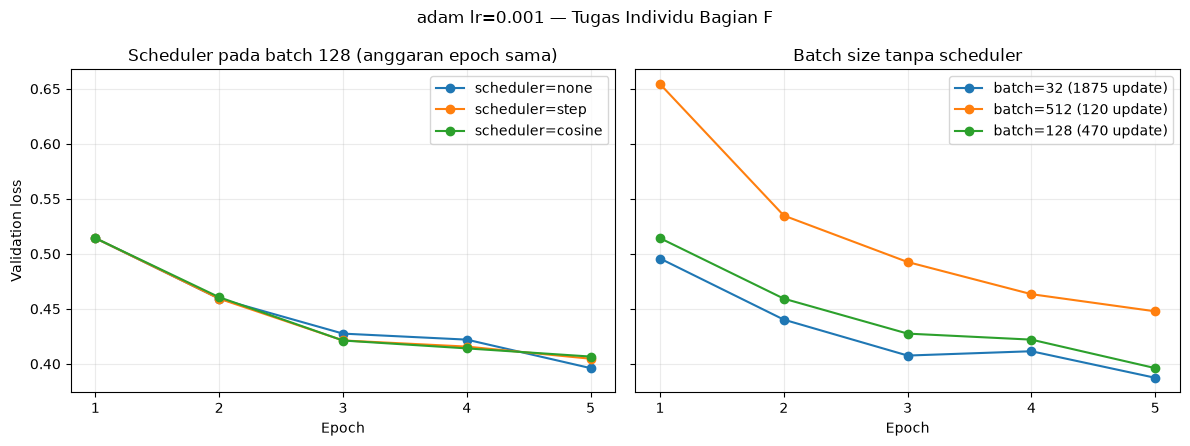

,run_id,scheduler,batch_size,n_update,learning_rate_final,val_loss,val_acc,runtime_s,runtime_per_epoch_s,status
0,scheduler_none_adam_lr0.001,none,128,470,0.0010,0.3961,0.8560,2.2091,0.4418,ok
1,scheduler_step_adam_lr0.001,step,128,470,0.0003,0.4047,0.8567,1.5702,0.3140,ok
2,batch_32_adam_lr0.001,none,32,1875,0.0010,0.3873,0.8633,3.0396,0.6079,ok
3,batch_512_adam_lr0.001,none,512,120,0.0010,0.4477,0.8400,1.0586,0.2117,ok
4,scheduler_cosine_adam_lr0.001,cosine,128,470,0.0000,0.4066,0.8550,2.1340,0.4268,ok
5,batch_128_adam_lr0.001,none,128,470,0.0010,0.3961,0.8560,1.6571,0.3314,ok


In [12]:
# Tiga run scheduler (None, 'step', 'cosine') pada anggaran epoch yang sama,
# lalu tiga run batch size (32, 128, 512). Laporkan kolom n_update.
# Run None, 'step', batch 32, dan batch 512 sudah tersedia dari bagian F Terbimbing;
# tambahkan run 'cosine' dan batch 128 lewat jalankan() yang sama.
tambahan = list(tambahan_terbimbing)

# Lengkapi run CosineAnnealingLR pada batch 128 (anggaran epoch sama).
_, history, note = jalankan(best_optimizer, best_lr, batch=BATCH, epoch=EPOCH,
                            scheduler='cosine')
note['run_id'] = f'scheduler_cosine_{best_optimizer}_lr{best_lr:g}'
note['experiment_group'] = 'scheduler'
tambahan.append(note)
riwayat_tambahan[note['run_id']] = history

# Lengkapi run batch 128 tanpa scheduler sebagai pembanding ketiga batch size.
_, history, note = jalankan(best_optimizer, best_lr, batch=128, epoch=EPOCH,
                            scheduler=None)
note['run_id'] = f'batch_128_{best_optimizer}_lr{best_lr:g}'
note['experiment_group'] = 'batch_size'
tambahan.append(note)
riwayat_tambahan[note['run_id']] = history

df_tambahan = pd.DataFrame(tambahan)
print(df_tambahan[['run_id', 'scheduler', 'batch_size', 'n_update',
                   'val_loss', 'val_acc', 'runtime_s']].to_string(index=False))
assert len(df_tambahan) == 6, 'harus ada enam run tambahan'
assert (df_tambahan['status'] == 'ok').all()
assert not df_tambahan['run_id'].duplicated().any(), 'run_id unik'
assert set(df_tambahan['scheduler'].astype(str)) == {'none', 'step', 'cosine'}
assert sorted(df_tambahan['batch_size'].unique().tolist()) == [32, 128, 512]

# Periksa jumlah update: ceil(n / batch) x EPOCH.
for ukuran in (32, 128, 512):
    harap = math.ceil(len(ds_latih) / ukuran) * EPOCH
    tercatat = int(df_tambahan.loc[df_tambahan['batch_size'] == ukuran, 'n_update'].iloc[0])
    print(f'batch {ukuran}: n_update tercatat = {tercatat}, hitungan = {harap}')
    assert tercatat == harap

# Grafik perbandingan enam run tambahan.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, group, title in zip(
        axes, ['scheduler', 'batch_size'],
        ['Scheduler pada batch 128 (anggaran epoch sama)', 'Batch size tanpa scheduler']):
    for note in tambahan:
        if note['experiment_group'] != group:
            continue
        history = riwayat_tambahan[note['run_id']]
        label = (f"scheduler={note['scheduler']}" if group == 'scheduler'
                 else f"batch={note['batch_size']} ({note['n_update']} update)")
        ax.plot(history['epoch'], history['val_loss'], marker='o', label=label)
    ax.set(title=title, xlabel='Epoch')
    ax.set_xticks(range(1, EPOCH + 1))
    ax.grid(alpha=0.25)
    ax.legend()
axes[0].set_ylabel('Validation loss')
fig.suptitle(f'{best_optimizer} lr={best_lr:g} — Tugas Individu Bagian F')
plt.tight_layout()
plt.show()

display(df_tambahan[['run_id', 'scheduler', 'batch_size', 'n_update',
                     'learning_rate_final', 'val_loss', 'val_acc',
                     'runtime_s', 'runtime_per_epoch_s', 'status']])

In [13]:
# Gabungkan seluruh run ke satu metrics.csv.
semua = pd.concat([
    pd.DataFrame(hasil_lr),        # 3 run baseline learning rate
    tabel,                         # 9 run grid optimizer
    pd.DataFrame([catatan_final]), # 1 run retrain final + evaluasi uji satu kali
    df_tambahan,                   # 6 run scheduler dan batch size
], ignore_index=True)
semua.insert(0, 'module', 'M03')
semua.insert(1, 'student_id', NIM)
semua.to_csv(f'M03_{NIM}_metrics.csv', index=False)
print(f'{len(semua)} baris tersimpan')
display(semua[['run_id', 'optimizer', 'learning_rate', 'scheduler', 'batch_size',
               'n_update', 'val_loss', 'val_acc', 'runtime_s', 'status']])
assert len(semua) >= 15, 'metrics.csv minimal berisi 15 run'
assert not semua['run_id'].duplicated().any(), 'setiap run harus tercatat satu kali'

19 baris tersimpan


,run_id,optimizer,learning_rate,scheduler,batch_size,n_update,val_loss,val_acc,runtime_s,status
0,baseline_sgd_lr0.001,sgd,0.0010,none,128,470,1.3709,0.6303,1.9968,ok
1,baseline_sgd_lr0.1,sgd,0.1000,none,128,470,0.4263,0.8477,1.7804,ok
2,baseline_sgd_lr1,sgd,1.0000,none,128,470,2.3389,0.3330,1.3797,ok
3,grid_sgd_lr0.01,sgd,0.0100,none,128,470,0.6183,0.7793,2.0602,ok
4,grid_sgd_lr0.1,sgd,0.1000,none,128,470,0.4263,0.8477,1.1307,ok
5,grid_sgd_lr0.5,sgd,0.5000,none,128,470,0.5676,0.7873,1.5219,ok
6,grid_momentum_lr0.01,momentum,0.0100,none,128,470,0.4161,0.8490,1.2470,ok
7,grid_momentum_lr0.05,momentum,0.0500,none,128,470,0.4118,0.8533,1.2259,ok
8,grid_momentum_lr0.1,momentum,0.1000,none,128,470,0.4621,0.8500,1.2234,ok
9,grid_adam_lr0.0001,adam,0.0001,none,128,470,0.5438,0.8073,2.0209,ok


In [14]:
# Bukti angka untuk pertanyaan analisis bagian G.
print('=== Sembilan run inti (urut validation loss) ===')
display(tabel[['run_id', 'optimizer', 'learning_rate', 'val_loss', 'val_acc',
               'grad_norm_mean', 'runtime_s', 'runtime_per_epoch_s', 'status']]
        .sort_values('val_loss'))

print('=== Tiga learning rate baseline SGD, validation loss per epoch ===')
for run_id, h in riwayat_lr.items():
    print(f"{run_id}: {[round(v, 4) for v in h['val_loss']]}")

print('=== Scheduler pada batch 128 ===')
display(df_tambahan[df_tambahan['experiment_group'] == 'scheduler'][
    ['run_id', 'scheduler', 'batch_size', 'n_update', 'learning_rate_final',
     'val_loss', 'val_acc', 'runtime_per_epoch_s']])

print('=== Batch size tanpa scheduler ===')
display(df_tambahan[df_tambahan['experiment_group'] == 'batch_size'][
    ['run_id', 'batch_size', 'n_update', 'val_loss', 'val_acc',
     'runtime_s', 'runtime_per_epoch_s']])

print('=== Run final (retrain + data uji satu kali) ===')
display(pd.DataFrame([catatan_final])[
    ['run_id', 'val_loss', 'val_acc', 'test_loss', 'test_acc', 'runtime_s']])

=== Sembilan run inti (urut validation loss) ===


,run_id,optimizer,learning_rate,val_loss,val_acc,grad_norm_mean,runtime_s,runtime_per_epoch_s,status
7,grid_adam_lr0.001,adam,0.0010,0.3961,0.8560,1.6189,1.4163,0.2833,ok
4,grid_momentum_lr0.05,momentum,0.0500,0.4118,0.8533,1.1442,1.2259,0.2452,ok
3,grid_momentum_lr0.01,momentum,0.0100,0.4161,0.8490,1.3728,1.2470,0.2494,ok
1,grid_sgd_lr0.1,sgd,0.1000,0.4263,0.8477,1.3347,1.1307,0.2261,ok
5,grid_momentum_lr0.1,momentum,0.1000,0.4621,0.8500,1.0801,1.2234,0.2447,ok
8,grid_adam_lr0.01,adam,0.0100,0.4794,0.8500,1.5884,1.3990,0.2798,ok
6,grid_adam_lr0.0001,adam,0.0001,0.5438,0.8073,1.2982,2.0209,0.4042,ok
2,grid_sgd_lr0.5,sgd,0.5000,0.5676,0.7873,1.2480,1.5219,0.3044,ok
0,grid_sgd_lr0.01,sgd,0.0100,0.6183,0.7793,1.2326,2.0602,0.4120,ok


=== Tiga learning rate baseline SGD, validation loss per epoch ===
baseline_sgd_lr0.001: [2.0425, 1.8277, 1.6469, 1.4949, 1.3709]
baseline_sgd_lr0.1: [0.6336, 0.5337, 0.5173, 0.4386, 0.4263]
baseline_sgd_lr1: [2.0318, 2.156, 1.9747, 2.2695, 2.3389]
=== Scheduler pada batch 128 ===


,run_id,scheduler,batch_size,n_update,learning_rate_final,val_loss,val_acc,runtime_per_epoch_s
0,scheduler_none_adam_lr0.001,none,128,470,0.0010,0.3961,0.8560,0.4418
1,scheduler_step_adam_lr0.001,step,128,470,0.0003,0.4047,0.8567,0.3140
4,scheduler_cosine_adam_lr0.001,cosine,128,470,0.0000,0.4066,0.8550,0.4268


=== Batch size tanpa scheduler ===


,run_id,batch_size,n_update,val_loss,val_acc,runtime_s,runtime_per_epoch_s
2,batch_32_adam_lr0.001,32,1875,0.3873,0.8633,3.0396,0.6079
3,batch_512_adam_lr0.001,512,120,0.4477,0.8400,1.0586,0.2117
5,batch_128_adam_lr0.001,128,470,0.3961,0.8560,1.6571,0.3314


=== Run final (retrain + data uji satu kali) ===


,run_id,val_loss,val_acc,test_loss,test_acc,runtime_s
0,final_retrain_adam_lr0.001,0.3961,0.856,0.427,0.8498,1.3095


## G. Pertanyaan analisis - bagian dari 15 poin · Tugas Individu

1. **Apakah optimizer dengan validation loss terendah juga yang tercepat?** Tidak. Adam `lr=0.001` memiliki validation loss terendah (0,3961) tetapi runtime 1,42 detik atau 0,283 detik per epoch — paling lambat di antara tiga pemenang; Momentum `lr=0.05` (0,4118) butuh 1,23 detik (0,245/epoch) dan SGD `lr=0.1` (0,4263) butuh 1,13 detik (0,226/epoch), jadi Adam membeli selisih validation loss 0,0157-0,0302 dengan waktu ±15-25% lebih lama. Di tingkat sembilan run, kecepatan juga tidak sejalan dengan kualitas: run tercepat `grid_sgd_lr0.1` (1,13 detik) berada di urutan keempat validation loss (0,4263), sedangkan dua run terlambat justru berada di urutan terburuk — `grid_sgd_lr0.01` (2,06 detik, validation loss terburuk 0,6183) dan `grid_adam_lr0.0001` (2,02 detik, 0,5438). Karena itu kualitas (validation loss) dan biaya (runtime) dilaporkan berdua; pemenang dipilih dari validation loss, sementara kecepatan dibaca sebagai trade-off.

2. **Mengapa learning rate terbaik Adam jauh lebih kecil daripada SGD?** SGD memakai langkah $\theta \leftarrow \theta - \eta g$, sehingga besar langkah bergantung langsung pada besaran gradien; dekat minimum gradien mengecil dan learning rate harus besar ($10^{-1}$) agar langkah masih berarti. Adam membagi gradien dengan $\sqrt{\hat v}$ (akar rata-rata kuadrat gradien) dan menambahkan momentum $\hat m$, sehingga langkah efektif per parameter kira-kira sebesar $\eta$ terlepas dari skala gradien. Karena langkahnya sudah dinormalisasi, $\eta=10^{-3}$ sudah cukup; $\eta$ sepuluh kali lipat justru membuat langkah terlalu besar. Buktinya pada grid bagian D: Adam $10^{-4}$ terlalu pelan (0,5438), $10^{-3}$ terbaik (0,3961), $10^{-2}$ memburuk (0,4794) — rentang optimal Adam bergeser satu order di bawah SGD yang terbaik di $10^{-1}$.

3. **Apa yang terjadi saat learning rate terlalu besar, dan pada epoch keberapa gejalanya terlihat?** Pada baseline SGD $\eta=1{,}0$ validation loss tidak menurun melainkan bergerigi lalu naik: $[2{,}0318 \rightarrow 2{,}1560 \rightarrow 1{,}9747 \rightarrow 2{,}2695 \rightarrow 2{,}3389]$ dan accuracy berhenti di 0,3330, sedangkan $\eta=0{,}1$ menurun mulus ke 0,4263. Gejala pertama tampak pada **epoch ke-2**, ketika loss naik dari 2,0318 menjadi 2,1560; sesudah itu kurva naik-turun (turun lagi di epoch 3, naik di epoch 4-5) — ciri langkah yang melewati lembah sehingga parameter memantul, bukan sekadar konvergen lambat. `grad_norm_mean` run ini juga tertinggi di antara ketiga baseline (1,4769 dibanding 1,3347 pada $\eta=0{,}1$).

4. **Apakah scheduler memperbaiki hasil pada anggaran epoch yang sama?** Tidak. Pada batch 128 dan 5 epoch yang sama: tanpa scheduler 0,3961, `StepLR(step_size=2, gamma=0.5)` 0,4047, `CosineAnnealingLR(T_max=5)` 0,4066 — keduanya lebih buruk. Penyebabnya anggaran yang terlalu pendek: `StepLR` memangkas learning rate dari 0,001 menjadi 0,0005 (epoch 3) lalu 0,00025 (epoch 5), dan cosine bahkan mendekati 0 di epoch akhir (`learning_rate_final` ≈ 0), padahal kurva loss masih menurun tajam selama lima epoch. Manfaat scheduler (langkah kecil untuk menyempurnakan sekitar minimum) baru terasa bila training jauh lebih lama; pada lima epoch scheduler hanya membuang sisa anggaran, sementara Adam sudah mengadaptasi langkahnya sendiri.

5. **Batch size mana yang direkomendasikan bila anggaran diukur dalam waktu?** Batch 128. Pada 5 epoch: batch 32 → 0,3873 dengan 0,6079 detik/epoch (total 3,04 detik); batch 128 → 0,3961 dengan ±0,33-0,44 detik/epoch (total ±1,66-2,21 detik, dua kali pengukuran pada konfigurasi identik); batch 512 → 0,4477 dengan 0,2117 detik/epoch (total 1,06 detik). Batch 32 terlalu mahal (±2,9 kali lebih lambat dari batch 512) hanya untuk selisih loss 0,0088 terhadap batch 128, sedangkan batch 512 menang tipis dari sisi waktu tetapi rugi jelas dari sisi kualitas (0,4477). Pada anggaran waktu 3,04 detik (yang dipakai batch 32 untuk 5 epoch), batch 512 dapat menjalankan ±14 epoch dan batch 128 ±9 epoch, sehingga pada anggaran waktu panjang batch besar sebaiknya diberi lebih banyak epoch. Untuk anggaran pendek, **batch 128** adalah kompromi terbaik antara kualitas (0,3961, hanya 0,0088 di atas batch 32) dan biaya per epoch.

**Keterbatasan.** Modul ini memakai subset $12\,000$ citra dan $5$ epoch. Dari hasil ini **tidak boleh** disimpulkan: (a) performa Adam/Momentum/SGD pada seluruh Fashion-MNIST atau dataset lain, karena hanya 20% data latih dan 5 epoch yang dipakai; (b) bahwa Adam selalu unggul, karena selisihnya hanya 0,0202 validation loss pada **satu seed** (24) tanpa pengulangan sehingga belum ada signifikansi statistik; (c) bahwa scheduler tidak berguna, karena pengujian hanya pada anggaran 5 epoch; (d) bahwa hasil berlaku untuk arsitektur lain (CNN, weight decay, augmentasi) karena hanya satu FNN $784 \rightarrow 128 \rightarrow 10$ yang diuji; (e) bahwa konfigurasi terbaik sudah global, karena tiap optimizer hanya diuji pada tiga learning rate; dan (f) urutan kecepatan sebagai benchmark, karena runtime diukur sekali di CPU dengan beban sistem tidak terkendali — terlihat dari run dengan konfigurasi identik yang mencatat 0,33 dan 0,44 detik per epoch.

## Checklist sebelum mengumpulkan

- [x] Identitas, seed, versi library, dan device tercantum.
- [x] Seluruh `TODO` dan `raise NotImplementedError` sudah diganti.
- [x] Split, normalisasi, dan jumlah parameter lolos sel pemeriksaan.
- [x] Seluruh run memanggil `jalankan()` yang sama.
- [x] `metrics.csv` memuat minimal 15 run, termasuk yang gagal.
- [x] Pemenang dipilih dari validation loss; data uji dipakai satu kali.
- [x] Grafik berlabel lengkap dan keterbatasan subset disebutkan.
- [x] Notebook lolos *Restart Kernel and Run All*.